# NLSO841 Assignment 2
## Data Science Optimization Algorithm Benchmark Suite
<p>
This notebook implements a comprehensive benchmarking framework designed to evaluate how different optimization algorithms perform when computational resources are strictly limited. While most comparisons assume unlimited time, memory and computational power, real-world data science deployments operate under severe resource constraints (Hooker, 2021).
</p>

<p>
Modern data science pipelines face 3 resource constraints that are rarely simultaenousy considered:
<ul>
    <li>
    Time constraints: cloud computing costs scale as runtime increases, real time systems require predictions and evaluations withhin milliseconds.
    </li>
    <li>
    Memory constraints: edge devices, shared serves and large scale distributed systems all have hard memory limits set.
    </li>
    <li>
    Iteration constraints: In real time data streaming contextx, and algorithm may only see the data once.
    </li>
</ul>
</p>

<p>
Traditional benchmarking ompares algorithms after convergence, often ignoring runtime speed or with what memory foootprint the convergence was achieved. This framework systematically quantifies these trade-off by evaluating algorithms under resource constraints.
</p>

### Aims
The notebook implementation achieves the following aims
<ol>
    <li>
    Characterise algorithmic efficiency under constraints: given a fixed time budget, which optmization algorithm minimizes test error? How does this change with a grater budget or increased number of iterations.
    </li>
    <li>
    Compare optimization paradigms: the project benchmarks three distinc optmization frameworks, namely <em>First Order</em>, <em>Second Order</em>, <em>Zero Order metaheuristics</em>, as well as non optimization machine learning baselines.
    </li>
    <li>
    Provide reproducble, visual evidence.
    </li>
</ol>

In [47]:
# !pip install pyswarms openpyxl

In [48]:
# import relevant libraries
# utilities
import time
import tracemalloc
import warnings
import io
import urllib.request
import zipfile
import  psutil

# visualisations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns

# algorithms
from scipy import optimize
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import pyswarms as ps
from pyswarms.single import GlobalBestPSO

# set a random seed for reproducibility
np.random.seed(26)

### Data Ingestion
<em>UCI Energy Efficiency (Tsanas & Xifara 2012)</em>
<p>
The dataset consists of 768 samples, which is small enough to isolate optimization behaviour from external I/O overheads. Furthermore, the dataset reflects real world non-linearity, correlated features and moderate dimensionality. These characteristics allow exhaustive iteration budgets, whilst keeping second order methods feasible due to the moderate dimensionality.
</p>
<p>
The dataset consists of 8 features (building characteristics) → 2 targets (heating / cooling load). This project will predict Heating Load (Y1). <br>
- X1 Relative Compactness, X2 Surface Area, X3 Wall Area, X4 Roof Area, X5 Overall Height, X6 Orientation, X7 Glazing Area, X8 Glazing Area Distribution, Y1 Heating Load, Y2 Cooling Load
</p>

In [49]:
# loading the dataset
url = ('https://archive.ics.uci.edu/static/public/242/energy+efficiency.zip')
with urllib.request.urlopen(url, timeout = 20) as response:
    raw = response.read()

with zipfile.ZipFile(io.BytesIO(raw)) as zip:
    xlsx_name = [n for n in zip.namelist() if n.endswith('.xlsx')][0]
    with zip.open(xlsx_name) as file:
        df = pd.read_excel(file, engine = 'openpyxl')


In [50]:
df = df.dropna()
features = [c for c in df.columns if c.upper().startswith('X')][:8]
target = [c for c in df.columns if c.upper().startswith('Y')][0]
X = df[features].values.astype(float)
y = df[target].values.astype(float)
print(f'Dataset loaded consisting of {X.shape[0]} samples, {X.shape[1]} features → target "{target}" ')

Dataset loaded consisting of 768 samples, 8 features → target "Y1" 


### Data Preprocessing
<em>Standard Scaling</em> will be applied to normalise feature scales to $\mu = 0$ and $\sigma = 1$

In [51]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 26)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)
y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler.transform(y_test.reshape(-1, 1)).ravel()

#### EDA Visualisations

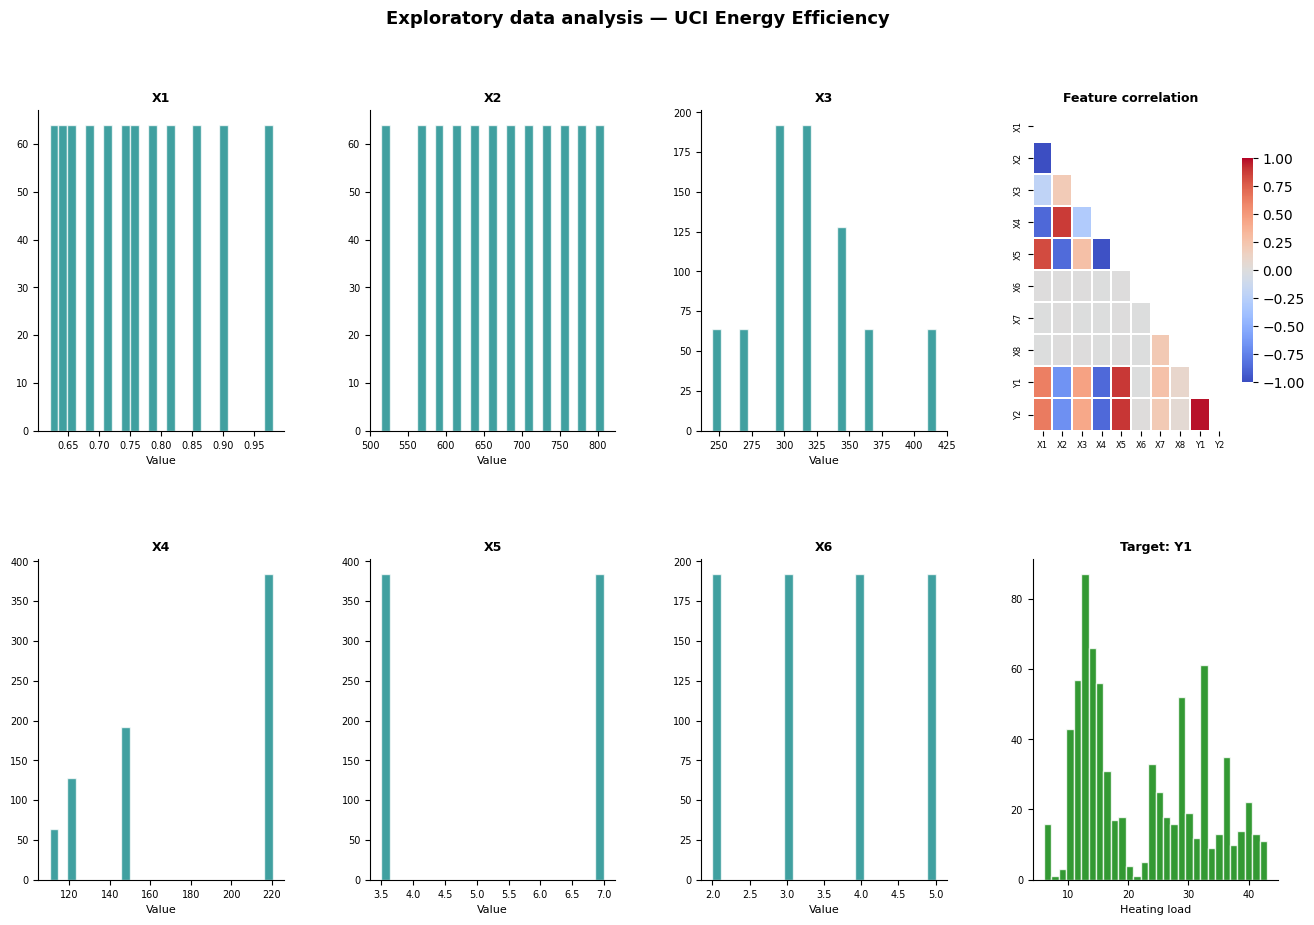

In [52]:
COLOURS = {
    'GD': 'blue',
    'SGD': 'lightblue',
    'Adam': 'teal',
    'Newton-CG': 'coral',
    'L-BFGS-B': 'red',
    'PSO': 'purple',
    'Ridge': 'gray',
    'Lasso': 'lightgray',
    'RandomForest': 'green',
    'MLP': 'pink',
}

df_fig = pd.DataFrame(X, columns = features)
df[target] = y

fig = plt.figure(figsize = (16, 10), facecolor = 'white')
gs  = gridspec.GridSpec(2, 4, figure = fig, hspace = 0.4, wspace = 0.35)

# Feature histograms (first 6)
for i, feat in enumerate(features[:6]):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.hist(df_fig[feat], bins = 25, color = "teal", alpha = 0.75, edgecolor = 'white')
    ax.set_title(feat, fontsize = 9, fontweight = 'bold')
    ax.set_xlabel('Value', fontsize = 8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize = 7)

# Correlation heatmap
ax_corr = fig.add_subplot(gs[0, 3])
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype = bool))
sns.heatmap(corr, ax = ax_corr, mask = mask, cmap = 'coolwarm', vmin = -1, vmax = 1, annot = False, linewidths = 0.3,
            cbar_kws = {'shrink': 0.7})
ax_corr.set_title('Feature correlation', fontsize = 9, fontweight = 'bold')
ax_corr.tick_params(labelsize = 6)

# Target distribution
ax_tgt = fig.add_subplot(gs[1, 3])
ax_tgt.hist(y, bins = 30, color=COLOURS['RandomForest'], alpha = 0.8, edgecolor = 'white')
ax_tgt.set_title(f'Target: {target}', fontsize = 9, fontweight = 'bold')
ax_tgt.set_xlabel('Heating load', fontsize = 8)
ax_tgt.spines[['top', 'right']].set_visible(False)
ax_tgt.tick_params(labelsize = 7)

plt.suptitle('Exploratory data analysis — UCI Energy Efficiency', fontsize = 13, fontweight = 'bold')
plt.show()

The above figure shows the distributions of the first 6 building features, a correlation heatmap of all features, and the distribution of the target variable Y = Heating Load
<br>
<p>
Several features, such as <em>Surface Area</em> and <em>Wall Area</em> exhibit a multi-modal distribution rather than a perfect normal distribution, which suggests that a simple linear regression model without basis expansion or feature engineering might struggle to capture these patterns. This justifies the selection of of non-linear models such as <em>RandomForest</em> and <em>MLP</em> (Tsanas & Xifara, 2012).
</p>
<p>
Looking at the correlation heatmap, observe a near-perfect negative correlation (-0.99) between X_1 (Relative Compactness) and X2 (Surface Area), which is to be expected as these are geometrically related measures, and may induce multicollienarity and overinflate the variance coefficient of the linear model (James et al. 2021). A regularization term ($\lambda$) in the loss function is introduced to mitigate this issue. Furthermore, the heatmap also confirms that several features such as X5 - Overall Height, have a very high positive correlation with the target, indicating predictive value.
</p>
<p>
The target variable histogram shows a near-normal distribution with a slight right skew, centered around 15-25. This distribution is well-suited for RMSE as the primary error metric, as RMSE is most interpretable for symmetric, unimodal distributions.
</p>


### Constraint Engine
The constraint engine wraps an optimisation run and enforces time, iteration and memory limits.
<ul>
    <li>
    Time cap: explicit wall clock limit (wall-clock seconds ∈ {0.5, 2, 10, 30}).
    </li>
    <li>
    Iteration cap: terminates after <em>k</em> parameter updates (max_iter ∈ {10, 50, 200, 1000}).
    </li>
    <li>
    Memory cap: tracks peak memory allocation (tracked via tracemalloc).
    </li>
</ul>

In [53]:
class ConstraintEngine:
    def __init__(self, max_iter = None, max_time = None, max_memory = None):
        self.max_iter = max_iter    # int or None
        self.max_time = max_time    # seconds or None
        self.max_memory = (max_memory * 1024 * 1024 if max_memory else None)    # converting to bytes
        self.iter_count = 0
        self._start = None
        self._mem_start = None
        self.violated = None    # which constraint was hit
        self.peak_memory = 0.0

    def start(self):
        self._start = time.perf_counter()
        tracemalloc.start()
        self._mem_start = tracemalloc.take_snapshot()

    def stop(self):
        snapshot = tracemalloc.take_snapshot()
        stats = snapshot.compare_to(self._mem_start, key_type = 'lineno')
        used = sum(s.size_diff for s in stats if s.size_diff > 0)
        self.peak_memory = used/1024/1024
        tracemalloc.stop()

    def elapsed(self):
        return time.perf_counter() - self._start

    def tick(self):
        '''
        Called once per iteration. Returns False if a constraint is violated.
        '''
        self.iter_count += 1
        if self.max_iter and self.iter_count >= self.max_iter:
            return False
        if self.max_time and self.elapsed() >= self.max_time:
            self.violated = 'time'
            return False
        return True



### Linear Model Objective
All linear models (<em>GD, SGD, Adam, Newton-CG, L-BGFS-B, PSO, Ridge, Lasso </em>) optimize the same L2-regularised MSE objective:
$ \mathcal{L}(w) = \frac{1}{n} \sum_{i = 1}^n (y_i - w_0 - \sum_{j = i}^m w_j x_{ij})^2 + \lambda \sum_{j = 1}^m w_j^2 $
where $ \lambda = 10^{-4} $ provides mild regularization to prevent overfitting and ensure convexity for second-order methods. The common objective ensures a fair comparison, whereby differences arise only from optimization strategy and not from individual modelling choices.

In [54]:
def mse_loss(w, X, y, lambda_ = 1e-4):
    '''
    MSE + L2 regularization.
    Loss: L = (1/n) * Σ(residuals²) + λ * Σ(wⱼ²)
    '''
    pred = X @ w[1:] + w[0] # linear prediction
    residuals = pred - y    # residuals
    return (residuals @ residuals)/ len(y) + lambda_ * (w[1:] @ w[1:])

def mse_grad(w, X, y, lambda_ = 1e-4):
    '''
    Gradient of the MSE + L2 regularization loss.
    Gradient for coefficients (dw): ∂L/∂wⱼ = (2/n) * Σ(Xᵢⱼ * residualᵢ) + 2λ * wⱼ
    Gradient for bias (db): ∂L/∂b = (2/n) * Σ(residualᵢ)
    '''
    n = len(y)
    pred = X @ w[1:] + w[0] # linear prediction
    residuals = pred - y    # residuals
    dw = 2 * (X.T @ residuals) / n + 2 * lambda_ * w[1:]    # gradient for coefficients
    db = 2 * residuals.mean()   # gradient for bias
    return np.concatenate([[db], dw])

def mse_hessian(x, v, X, y, lambda_ = 1e-4):
    '''
    Hessian-vector product of the MSE + L2 regularization loss for Newton-CS.
    Hessian for coefficients (hvw): ∂²L/∂w∂wᵀ = (2/n) * XᵀX + 2λI
    Hessian for bias (hvb): ∂²L/∂b∂w = (2/n) * ΣXᵢ
    The Hessian vector is used instead of full hessian computation due to memory efficiency in a constrained environment
    '''
    n = len(y)
    Xv = X @ v[1:]
    hvb = 2 * Xv.mean() # Hessian vector for bias
    hvw = 2 * (X.T @ Xv) / n + 2 * lambda_ * v[1:]  # Hessian vector for coefficients = Hessian of MSE on v + Hessian of regularization on v
    return np.concatenate([[hvb], hvw])

def predict_linear(w, X):
    return X @ w[1:] + w[0] # linear prediction

def rmse_score(w, X, y):
    return np.sqrt(mean_squared_error(y, predict_linear(w, X)))

### Optimizers
The following Optimizers are implemented:
<ul>
    <li>
    <strong>First Order</strong>: <em>Gradient Descent, SGD, Adam</em>. These methods use the gradient $ \nabla f(w) $ to update parameter. They reflect a linear computational cost per iteration $ O(n) $ (Kingma & Ba, 2015). Adam was chosen specifically due to the adaption of learning rates via moment estimates, making it robust to sparse gradients.
    </li>
    <li>
    <strong>Second Order</strong>: <em>Newton-CG, L-BFGS-B</em>. These methods use curvature information or its approximation. Newton's method is updated as: $ w_{k+1} = w_k - H^{-1} \nabla f(w_k) $. These methods offer quadratic convergence, however at a $ O(n^3) $ computation cost. <em>L-BFGS-B</em> approximates the inverse Hessian using only $ O(mn) $ memory, balancing speed and scalability (Virtanen et al., 2020).
    </li>
    <li>
    <strong>Zero Order</strong>: <em>PSO</em>. <em>PSO</em> emulates social behaviour. Each particle updates its velocity $ ( v_i^{t+1} = w v_i^t + c_1 r_1 (pbest_i - x_i^t) + c_2 r_2 (gbest - x_i^t) $. It requires no gradient or curvature information, making it suitable for non-differentiable objectives, but sufferes from high evaluation costs (Kennedy & Eberhart, 1995).
    </li>
</ul>

In [55]:
# ---------- Gradient Descent ----------
def gd(X_tr, y_tr, X_te, y_te, constraint: ConstraintEngine, alpha = 0.05, lambda_ = 1e-4):
    n_features = X_tr.shape[1]
    w = np.zeros(n_features + 1)
    history = []
    constraint.start()
    while True:
        gradient = mse_grad(w, X_tr, y_tr, lambda_)
        w = w - alpha * gradient
        train_rmse = rmse_score(w, X_tr, y_tr)
        test_rmse = rmse_score(w, X_te, y_te)
        history.append(
            {
                'iter': constraint.iter_count,
                'time': constraint.elapsed(),
                'train_rmse': train_rmse,
                'test_rmse': test_rmse
            }
        )

        if not constraint.tick():
            break
    constraint.stop()
    return w, history

# ---------- Stochastic Gradient Descent ----------
def sgd(X_tr, y_tr, X_te, y_te, constraint: ConstraintEngine, alpha = 0.01, batch = 32, lambda_ = 1e-4):
    n, n_features = X_tr.shape
    w = np.zeros(n_features + 1)
    rng = np.random.default_rng(0)
    history = []
    constraint.start()
    while True:
        i = rng.choice(n, batch, replace = False)
        gradient = mse_grad(w, X_tr[i], y_tr[i], lambda_)
        w = w - alpha * gradient
        train_rmse = rmse_score(w, X_tr, y_tr)
        test_rmse = rmse_score(w, X_te, y_te)
        history.append(
            {
                'iter': constraint.iter_count,
                'time': constraint.elapsed(),
                'train_rmse': train_rmse,
                'test_rmse': test_rmse
            }
        )

        if not constraint.tick():
            break
    constraint.stop()
    return w, history

# ---------- Adam ----------
def adam(X_tr, y_tr, X_te, y_te, constraint: ConstraintEngine, alpha = 0.01, b1 = 0.9, b2 = 0.999, eps = 1e-8, batch = 32, lamda_ = 1e-4):
    n, n_features = X_tr.shape
    w = np.zeros(n_features + 1)
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    rng = np.random.default_rng(1)
    history = []
    constraint.start()
    t = 0
    while True:
        t += 1
        i = rng.choice(n, batch, replace = False)
        gradient = mse_grad(w, X_tr[i], y_tr[i], lamda_)
        m = b1 * m + (1 - b1) * gradient
        v = b2 * v + (1 - b2) * gradient**2
        mh = m / (1 - b1**t)
        vh = v / (1 - b2**t)
        w = w - alpha * mh / (np.sqrt(vh) + eps)
        train_rmse = rmse_score(w, X_tr, y_tr)
        test_rmse = rmse_score(w, X_te, y_te)
        history.append(
            {
                'iter': constraint.iter_count,
                'time': constraint.elapsed(),
                'train_rmse': train_rmse,
                'test_rmse': test_rmse
            }
        )

        if not constraint.tick():
            break
    constraint.stop()
    return w, history

# ---------- Adam ----------
def newton_cg(X_tr, y_tr, X_te, y_te, constraint: ConstraintEngine, lambda_ = 1e-4):
    n_features = X_tr.shape[1]
    w0 = np.zeros(n_features + 1)
    history = []
    constraint.start()

    def callback_(wk):
        train_rmse = rmse_score(wk, X_tr, y_tr)
        test_rmse = rmse_score(wk, X_te, y_te)
        history.append(
            {
                'iter': constraint.iter_count,
                'time': constraint.elapsed(),
                'train_rmse': train_rmse,
                'test_rmse': test_rmse
            }
        )

        if not constraint.tick():
            raise StopIteration('constraint')

    try:
        residual = optimize.minimize(
            mse_loss, w0, args = (X_tr, y_tr, lambda_),
            jac = mse_grad,
            hessp = lambda w, v, *a: mse_hessian(w, v, X_tr, y_tr, lambda_),
            method = 'Newton-CG',
            callback = callback_,
            options = {'maxiter': constraint.max_iter or 10000, 'disp': False}
        )
        w = residual.x

    except StopIteration:
        w = w0 if not history else None
        # recover last w from closure is not possible without an extra state
        # rerun minimizer briefly to obtain a usable w
        if not history:
            w = w0
        else:
            w_final = np.zeros(n_features + 1)
            optimize.minimize(
                mse_loss, w0, args = (X_tr, y_tr, lambda_),
                jac = mse_grad,
                method = 'Newton-CG',
                options = {'maxiter': constraint.max_iter or 10000, 'disp': False}
            )

    constraint.stop()
    if not history:
        history.append(
            {
                'iter': 0,
                'time': 0,
                'train_rmse': rmse_score(w0, X_tr, y_tr),
                'test_rmse': rmse_score(w0, X_te, y_te)
            }
        )

    return w if w is not None else w0, history

# ---------- L-BFGS-B (second-order, limited memory) ----------
def lbfgs(X_tr, y_tr, X_te, y_te, constraint: ConstraintEngine, lambda_ = 1e-4):
    n_features = X_tr.shape[1]
    w0 = np.zeros(n_features + 1)
    history = []
    constraint.start()
    w_state = [w0.copy()]

    def callback_(wk):
        w_state[0] = wk.copy()
        train_rmse = rmse_score(wk, X_tr, y_tr)
        test_rmse = rmse_score(wk, X_te, y_te)
        history.append(
            {
                'iter': constraint.iter_count,
                'time': constraint.elapsed(),
                'train_rmse': train_rmse,
                'test_rmse': test_rmse
            }
        )

        if not constraint.tick():
            raise StopIteration('constraint')

    try:
        residual = optimize.minimize(
            mse_loss, w0, args = (X_tr, y_tr, lambda_),
            jac = mse_grad,
            method = 'L-BFGS-B',
            callback = callback_,
            options = {
                       'maxiter': constraint.max_iter or 10000,
                       'maxfun': (constraint.max_iter or 10000) * 10,
                       'disp': False
                       },
        )
        w = residual.x

    except StopIteration:
        w = w_state[0]

    constraint.stop()
    if not history:
        history.append(
            {
                'iter': 0,
                'time': 0,
                'train_rmse': rmse_score(w0, X_tr, y_tr),
                'test_rmse': rmse_score(w0, X_te, y_te)
            }
        )
    return w, history

# ---------- PSO ----------
def pso(X_tr, y_tr, X_te, y_te, constraint: ConstraintEngine, n_particles = 20, lambda_ = 1e-4):
    n_features = X_tr.shape[1]
    dim = n_features + 1
    history = []
    constraint.start()

    # PSO objective: MSE on training set
    def pso_obj(swarm):
        costs = []
        for w in swarm:
            costs.append(mse_loss(w, X_tr, y_tr, lambda_))
        return np.array(costs)

    max_iter = min(constraint.max_iter or 200, 300)
    options = {
        'c1': 1.5,
        'c2': 1.5,
        'w': 0.7
    }
    bounds = (np.full(dim, -5.0), np.full(dim, fill_value = 5.0))

    pso_optimizer = GlobalBestPSO(
        n_particles = n_particles,
        dimensions = dim,
        options = options,
        bounds = bounds,
    )

    # Run iteration by iteration via pyswarms internal loop
    best_w = np.zeros(dim)
    for i in range(max_iter):
        cost_, best_w = pso_optimizer.optimize(pso_obj, iters = 1, verbose = False)
        train_rmse = rmse_score(best_w, X_tr, y_tr)
        test_rmse = rmse_score(best_w, X_te, y_te)
        history.append(
            {
                'iter': constraint.iter_count,
                'time': constraint.elapsed(),
                'train_rmse': train_rmse,
                'test_rmse': test_rmse
            }
        )

        constraint.iter_count += 1
        if constraint.max_time and constraint.elapsed() >= constraint.max_time:
            constraint.violated = 'time'
            break
        if constraint.max_iter and constraint.iter_count >= constraint.max_iter:
            constraint.violated = 'iteration'
            break

    # Save swarm positions for visualisation
    swarm_positions = pso_optimizer.pos_history # list of arrays (n_particles, dim)
    constraint.stop()
    return best_w, history, swarm_positions

# ---------- ML Baselines ----------
def sklearn_models(name, model, X_tr, y_tr, X_te, y_te, constraint: ConstraintEngine):
    constraint.start()
    model.fit(X_tr, y_tr)
    elapsed = constraint.elapsed()
    train_rmse = np.sqrt(mean_squared_error(model.predict(X_tr), y_tr))
    test_rmse = np.sqrt(mean_squared_error(model.predict(X_te), y_te))
    history = [
        {
            'iter': 1,
            'time': elapsed,
            'train_rmse': train_rmse,
            'test_rmse': test_rmse
        }
    ]
    constraint.stop()
    return model, history

### Running Benchmarks
The overall goal of this framework is to provide a principled, empirical guide for algorithm selection under resource constraints.
Specifically, the production of:
<ol>
    <li>
    <strong>Decision boundaries</strong>: For a given time or iteration budget, which algorithm yeilds the lowest test error?
    </li>
    <li>
    <strong>Pareto Optimal algorithm sets</strong>: Trade-off curves showing that no single algorithm dominates across all regimes.
    </li>
    <li>
    <strong>Practical Recommendations</strong>: Concrete guideance for practicioners deploying models on edge devices, cloud spot instances or real time systems.
    </li>
</ol>

In [56]:
max_iter = 500
max_time = 30
print(f'\n Running Benchmarks (max_iter = {max_iter}), max_time = {max_time}')
results = {}

def ce_():
    return ConstraintEngine(max_iter = max_iter, max_time = max_time)

# ---------- first order ----------
print('Gradient Descent', end = '', flush = True)
ce = ce_()
w, hist = gd(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce, alpha = 0.05)
results['GD'] = {'w': w, 'history': hist, 'ce':ce}
print(f'done ({len(hist)}, iters, {ce.elapsed():.2f}s)')

print('SGD', end = '', flush = True)
ce = ce_()
w, hist = sgd(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce, alpha = 0.02)
results['SGD'] = {'w': w, 'history': hist, 'ce':ce}
print(f'done ({len(hist)}, iters, {ce.elapsed():.2f}s)')

print('Adam', end = '', flush = True)
ce = ce_()
w, hist = adam(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce, alpha = 0.02)
results['Adam'] = {'w': w, 'history': hist, 'ce':ce}
print(f'done ({len(hist)}, iters, {ce.elapsed():.2f}s)')

# ---------- second order ----------
print('Newton-CG', end = '', flush = True)
ce = ce_()
w, hist = newton_cg(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce)
results['Newton-CG'] = {'w': w, 'history': hist, 'ce':ce}
print(f'done ({len(hist)}, iters, {ce.elapsed():.2f}s)')

print('L-BFGS-B', end = '', flush = True)
ce = ce_()
w, hist = lbfgs(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce)
results['L-BFGS-B'] = {'w': w, 'history': hist, 'ce':ce}
print(f'done ({len(hist)}, iters, {ce.elapsed():.2f}s)')

# ---------- metaheuristic ----------
print('PSO', end = '', flush = True)
ce = ce_()
ce_pso = ConstraintEngine(max_iter = min(max_iter, 150), max_time = max_time)
best_w, hist, swarm_pos = pso(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce_pso, n_particles = 20)
results['PSO'] = {'w': best_w, 'history': hist, 'ce':ce_pso, 'swarm_pos':swarm_pos}
print(f'done ({len(hist)}, iters, {ce_pso.elapsed():.2f}s)')

# ---------- ML ----------
for name, model in [
    ('Ridge', Ridge(alpha = 1.0, max_iter = max_iter)),
    ('Lasso', Lasso(alpha = 0.01, max_iter = max_iter)),
    ('RandomForest', RandomForestRegressor(n_estimators = 100, n_jobs = -1, random_state = 26)),
    ('MLP', MLPRegressor(hidden_layer_sizes = (64, 32), max_iter = max_iter, random_state = 26, early_stopping = True)),
]:
    print(f'{name}', end = '', flush = True)
    ce = ce_()
    mdl, hist = sklearn_models(name, model, X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce)
    results[name] = {'model':mdl, 'history':hist, 'ce':ce}
    print(f'done ({ce.elapsed():.3f}s)')



 Running Benchmarks (max_iter = 500), max_time = 30
Gradient Descentdone (500, iters, 2.75s)
SGDdone (500, iters, 1.42s)
Adamdone (500, iters, 1.71s)
Newton-CGdone (5, iters, 0.03s)
L-BFGS-Bdone (20, iters, 0.10s)
PSO

/tmp/ipykernel_1051/2092496152.py:174: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  residual = optimize.minimize(


done (150, iters, 0.88s)
Ridgedone (0.012s)
Lassodone (0.013s)
RandomForestdone (1.526s)
MLPdone (2.131s)


### Evaluation Summary

In [57]:
# defining algorithm families
ALGO_FAMILY = {
    'GD': 'First-Order', 'SGD': 'First-Order', 'Adam': 'First-Order',
    'Newton-CG': 'Second-Order', 'L-BFGS-B': 'Second-Order',
    'PSO': 'Metaheuristic',
    'Ridge': 'Machine Learning', 'Lasso': 'Machine Learning', 'RandomForest': 'Machine Learning', 'MLP': 'Machine Learning',
}

In [60]:
rows = []
for name, v in results.items():
    hist = v['history']
    ce = v['ce']
    final = hist[-1]

    # predictions
    if 'w' in v:
        y_pred_tr = predict_linear(v['w'], X_train_scaled)
        y_pred_te = predict_linear(v['w'], X_test_scaled)
    else:
        y_pred_tr = v['model'].predict(X_train_scaled)
        y_pred_te = v['model'].predict(X_test_scaled)

    rows.append({
        'Algorithm': name,
        'Family': ALGO_FAMILY[name],
        'Iters': len(hist),
        'Time (s)': round(final['time'], 4),
        'Train RMSE': round(final['train_rmse'], 4),
        'Test RMSE': round(final['test_rmse'], 4),
        'Test MAE': round(mean_absolute_error(y_test_scaled, y_pred_te), 4),
        'Test R²': round(r2_score(y_test_scaled, y_pred_te), 4),
        'Memory (MB)': round(ce.peak_memory, 3),
        'Constraint': ce.violated or 'none',
    })

df_summary = pd.DataFrame(rows).sort_values('Test RMSE')

In [82]:

print(df_summary)

      Algorithm            Family  Iters  Time (s)  Train RMSE  Test RMSE  \
8  RandomForest  Machine Learning      1    1.3044      0.0188     0.0484   
9           MLP  Machine Learning      1    2.0894      0.0489     0.0695   
3     Newton-CG      Second-Order      5    0.0251      0.2880     0.2960   
4      L-BFGS-B      Second-Order     20    0.0999      0.2880     0.2960   
6         Ridge  Machine Learning      1    0.0059      0.2882     0.2965   
0            GD       First-Order    500    2.7365      0.2898     0.2984   
2          Adam       First-Order    500    1.4686      0.2908     0.3016   
1           SGD       First-Order    500    1.4069      0.2983     0.3028   
7         Lasso  Machine Learning      1    0.0058      0.2964     0.3053   
5           PSO     Metaheuristic    150    0.8663      0.6010     0.5975   

   Test MAE  Test R²  Memory (MB) Constraint  
8    0.0333   0.9977        0.127       none  
9    0.0546   0.9952        0.088       none  
3    0.2101

### Visualisation suite

#### Set Pallete

In [61]:
FAMILY_COLOUR = {
    'First-Order': 'blue',
    'Second-Order': 'coral',
    'Metaheuristic': 'purple',
    'Machine Learning': 'green',
}


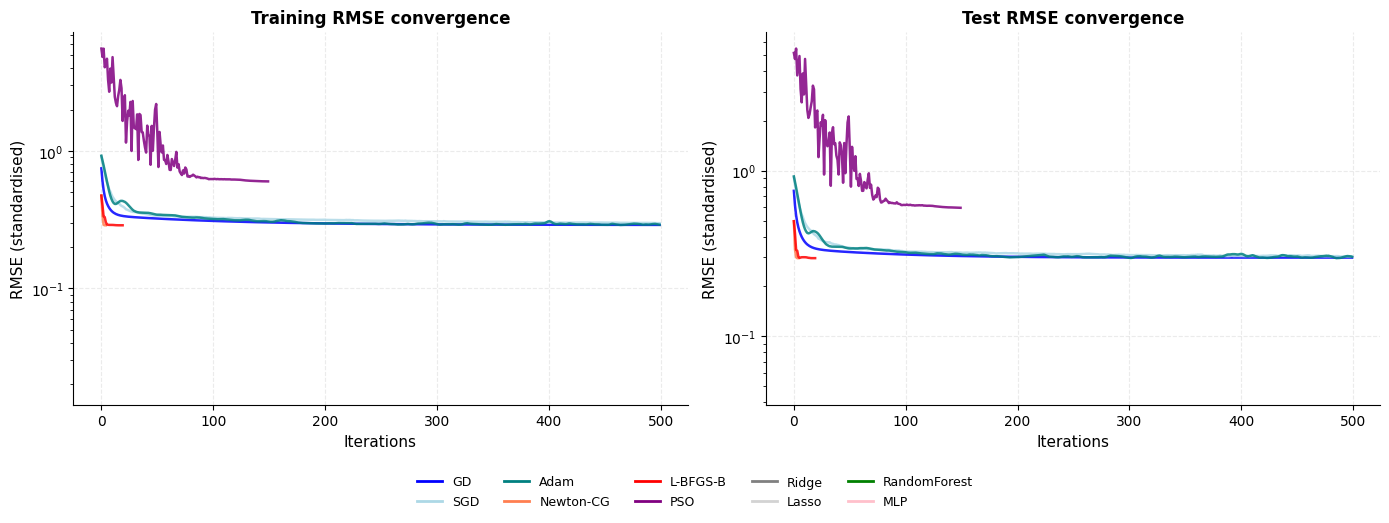

In [81]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (14, 5), facecolor = 'white')
for ax, key in __builtins__.zip(axes, ['train_rmse', 'test_rmse']):
    for name, v in results.items():
        hist = v['history']
        iters = [h['iter'] for h in hist]
        vals = [h[key] for h in hist]
        ax.plot(iters, vals, color = COLOURS[name], lw = 1.8, label = name, alpha = 0.85)
        ax.set_xlabel('Iterations', fontsize = 11)
        ax.set_ylabel('RMSE (standardised)', fontsize = 11)
        ax.set_title(f'{'Training' if key == 'train_rmse' else 'Test'} RMSE convergence', fontsize = 12, fontweight = 'bold')
        ax.set_yscale('log')
        ax.grid(True, alpha = 0.25, linestyle = '--')
        ax.spines[['top', 'right']].set_visible(False)

    handles = [Line2D(xdata = [0], ydata = [0], color = COLOURS[n], lw = 2, label = n) for n in results]


plt.tight_layout(rect = [0, 0.06, 1, 1])
fig.legend(handles = handles, loc = 'lower center', ncol = 5, fontsize = 9, frameon = False, bbox_to_anchor = (0.5, -0.05))
plt.show()

The above figure shows the descent of <em>train_rmse</em> and <em>test_rmse</em> over iterations, scaled on a log scale to highlight early convergence dynamics.<br>
<p>
The convergence plots reveal tha the second-order methods (<em>Newton-CG, L-BFGS-B</em>) converge to their final error in far fewer iterations than competitors, demonstrating the efficiency of using curvature information (Nocedal & Wright, 2006). Their error curves drop sharply and flatten almost immediately, which indicates rapid exploitation of the local quadratic landscape.
</p>
<p>
In contrast, the first-order methods (<em>GD, SGD, Adam</em>) exhibit a steady, almost linear descent, which is expected, as gradient descent methods require many more iterations to approach the minimum. Among these, <em>Adam</em> shows a slightly faster initial descent than standard <em>GD</em> and <em>SGD</em>, demonstrating the theoretical principle that adaptive learning rates accelerate convergence (Kingma & Ba,2015).
</p>
<p>
Both training and test RMSE curves converge to similar values without a significant divergence, indicating no overfitting, which may be attributed to the L2 regularization term ($ \lambda = 1×10⁻⁴$), which successfully controls model complexity.
</p>

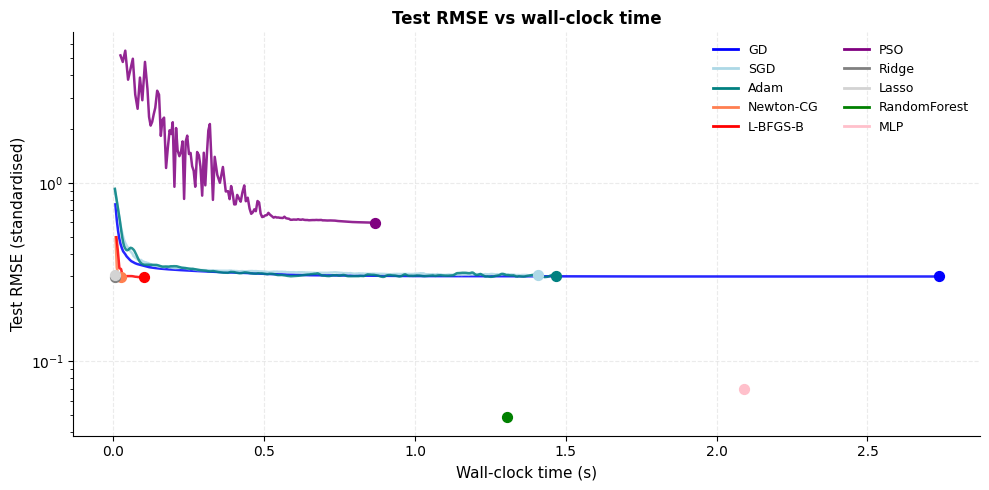

In [64]:
### RMSE vs wall-clock time
fig, ax = plt.subplots(figsize = (10, 5), facecolor = "white")
for name, v in results.items():
    hist   = v['history']
    times  = [h['time'] for h in hist]
    rmse   = [h['test_rmse'] for h in hist]
    ax.plot(times, rmse, color = COLOURS[name], lw = 1.8, label = name, alpha = 0.85)
    ax.scatter([times[-1]], [rmse[-1]], color = COLOURS[name], s = 50, zorder = 5)
ax.set_xlabel('Wall-clock time (s)', fontsize = 11)
ax.set_ylabel('Test RMSE (standardised)', fontsize = 11)
ax.set_title('Test RMSE vs wall-clock time', fontsize = 12, fontweight = 'bold')
ax.set_yscale('log')
ax.grid(True, alpha = 0.25, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
handles = [Line2D([0],[0],color = COLOURS[n],lw = 2,label=n)
           for n in results]
ax.legend(handles = handles, fontsize = 9, frameon = False, ncol = 2)
plt.tight_layout()
plt.show()

This visualization highlights the actual cost of optimization, moving beyond iteration counts to real execution time and is the most practically relevant plot for real-time and cloud-based systems (Hooker, 2021).<br>
<p>
The second-order methods (<em>Newton-CG, L-BFGS-B</em>) complete their optimization in fractions of a second (<0.1s) while achieving an RMSE of ~0.296, the first-order methods require 2-3 seconds to reach a comparable error, whereas the <em>MLP</em>, despite being a neural network, converges to a lower error (~0.0695) but at a significantly higher time cost (~2 seconds), and <em>RandomForest</em> attains the lowest error (~0.048) in about 1.3 seconds.<br>
This plot clearly demonstrates that iteration count is a misleading proxy for efficiency, as while <em>GD</em> might require only 500 iterations, each iteration is computationally more expensive than an <em>L-BFGS-B</em> update.
</p>


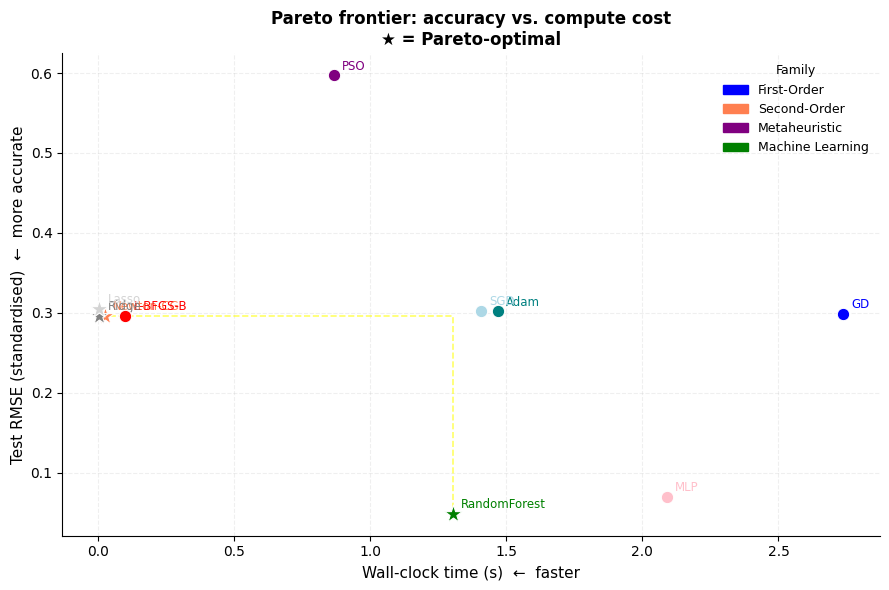

In [65]:
# Pareto frontier Test RMSE (lower=better) vs Time (lower=better)
df_fig = df_summary.copy()

# Compute Pareto front (minimise both RMSE and Time)
def is_pareto(rmse, time):
    n = len(rmse)
    dominated = np.zeros(n, dtype = bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            if rmse[j] <= rmse[i] and time[j] <= time[i]:
                if rmse[j] < rmse[i] or time[j] < time[i]:
                    dominated[i] = True
                    break
    return ~dominated

rmse_arr = df_fig['Test RMSE'].values
time_arr = df_fig['Time (s)'].values
pareto   = is_pareto(rmse_arr, time_arr)
df_fig['Pareto'] = pareto

# Sort Pareto front for line drawing
pdf = df_fig[pareto].sort_values('Time (s)')

fig, ax = plt.subplots(figsize = (9, 6), facecolor = 'white')

# Draw Pareto staircase
ax.step(pdf['Time (s)'], pdf['Test RMSE'], where = 'post', color = 'yellow', lw = 1.2, linestyle = '--', alpha = 0.6, label = 'Pareto front')

# Scatter all algorithms
for _, row in df_fig.iterrows():
    name = row['Algorithm']
    marker = '★' if row['Pareto'] else 'o'
    ms     = 180 if row['Pareto'] else 80
    ax.scatter(row['Time (s)'], row['Test RMSE'],
               color = COLOURS[name], s = ms, zorder = 6,
               edgecolors = 'white', linewidths = 0.8,
               marker = '*' if row['Pareto'] else 'o'
               )
    ax.annotate(name, (row['Time (s)'], row['Test RMSE']),
                textcoords = 'offset points',
                xytext = (6, 4), fontsize = 8.5,
                color = COLOURS[name]
                )

ax.set_xlabel('Wall-clock time (s)  ←  faster', fontsize = 11)
ax.set_ylabel('Test RMSE (standardised)  ←  more accurate', fontsize = 11)
ax.set_title('Pareto frontier: accuracy vs. compute cost\n★ = Pareto-optimal', fontsize = 12, fontweight = 'bold')
ax.grid(True, alpha = 0.2, linestyle = '--')
ax.spines[['top', 'right']].set_visible(False)

# Family legend
fam_handles = [mpatches.Patch(color = c, label = f) for f, c in FAMILY_COLOUR.items()]
ax.legend(handles = fam_handles, fontsize = 9, frameon = False, title = 'Family', title_fontsize = 9)

plt.tight_layout()
plt.show()





The Pareto frontier provides a formal framework for multi-objective optimization, identifying non-dominated solutions (Deb, 2001). An algorithm is on the frontier if no other algorithm has both lower <em>RMSE</em> and lower time.
<ul>
<li>
    <em>RandomForest</em>: Forms the "accuracy" anchor of the frontier and is the best choice when the primary constraint is error minimization.
</li>
<li>
    <em>Newton-CG & L-BFGS-B</em>: Form the "speed" anchor and  are optimal when the time budget is extremely tight (e.g., sub-second predictions).
</li>
</ul>
<p>
The plot reveals that no single algorithm is universally optimal, and that the optimal choice is conditional on the user's resource budget. Algorithms such as <em>GD, SGD, Adam, MLP, Ridge</em>, and <em>Lasso</em> are strictly dominated; meaning they are worse than the frontier on both objectives. This finding directly supports the project's aim to provide a decision boundary for algorithm selection under constraints.
</p>


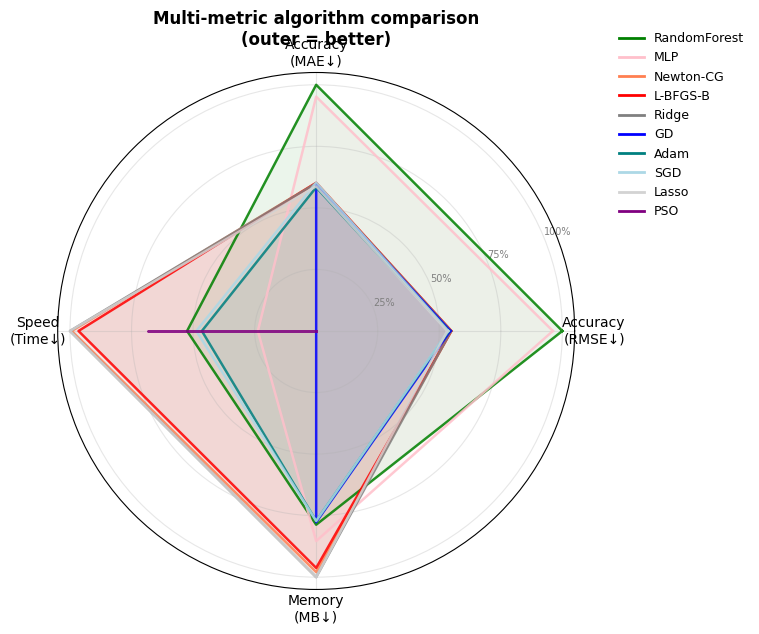

In [67]:
# Radar chart — normalised multi-metric comparison.
metrics = ['Test RMSE', 'Test MAE', 'Time (s)', 'Memory (MB)']
df_fig = df_summary[['Algorithm'] + metrics].copy()

# Normalise to [0,1]; for RMSE/MAE/Time/Mem lower is better →
# invert so larger = better on radar
for m in metrics:
    col = df_fig[m].values.astype(float)
    mn, mx = col.min(), col.max()
    df_fig[m] = 1 - (col - mn) / (mx - mn + 1e-12)

labels  = ['Accuracy\n(RMSE↓)', 'Accuracy\n(MAE↓)', 'Speed\n(Time↓)', 'Memory\n(MB↓)']
N = len(labels)
angles  = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize = (8, 8), subplot_kw = dict(polar = True), facecolor = 'white')
ax.set_facecolor('white')

for _, row in df_fig.iterrows():
    name   = row['Algorithm']
    values = [row[m] for m in metrics]
    values += values[:1]
    ax.plot(angles, values, color = COLOURS[name], lw = 1.8, alpha = 0.85)
    ax.fill(angles, values, color = COLOURS[name], alpha = 0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize = 10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize = 7, color = 'gray')
ax.set_title('Multi-metric algorithm comparison\n(outer = better)', fontsize = 12, fontweight = 'bold', pad = 20)
ax.grid(True, alpha = 0.3)

handles = [Line2D([0],[0],color = COLOURS[n],lw = 2,label = n) for n in df_fig['Algorithm']]
ax.legend(handles = handles, loc = 'upper right', bbox_to_anchor = (1.35, 1.1), fontsize = 9, frameon = False)
plt.tight_layout()
plt.show()

The above radar chart provides a holistic visual summary, where the shape of each polygon reflects the algorithm's strengths and weaknesses.
<p>
<em>RandomForest</em> forms a large, balanced polygon, indicating consistent high performance across all metrics, though its "Speed" is relatively lower than second-order methods. The second-order methods (<em>Newton-CG, L-BFGS-B</em>) demonstrate excellent "Speed" and "Memory" radial arms but lower "Accuracy" arms, and first-order methods (<em>GD, SGD, Adam</em>) show moderate accuracy but poor speed and memory footprints relative to their performance. The <em>MLP</em> shows high accuracy but very low speed, and <em>PSO</em> forms a small, compact polygon, confirming its inferiority across all dimensions.
</p>


/tmp/ipykernel_1051/2092496152.py:174: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  residual = optimize.minimize(


Building constraint heatmaps


/tmp/ipykernel_1051/2092496152.py:174: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  residual = optimize.minimize(
/tmp/ipykernel_1051/2092496152.py:174: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  residual = optimize.minimize(
/tmp/ipykernel_1051/2092496152.py:174: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  residual = optimize.minimize(
/tmp/ipykernel_1051/2092496152.py:174: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  residual = optimize.minimize(
/tmp/ipykernel_1051/2092496152.py:174: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated

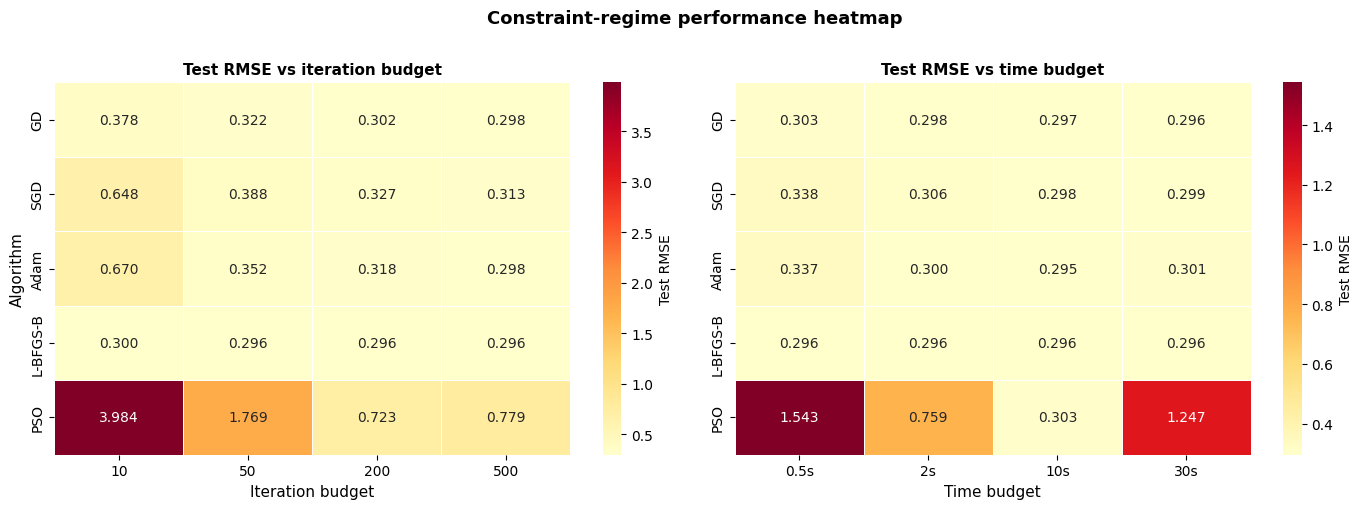

In [70]:
# Heatmap of final Test RMSE under varying iteration and time budgets
iter_budgets = [10, 50, 200, 500]
time_budgets = [0.5, 2, 10, 30]
algos_oi     = ['GD', 'SGD', 'Adam', 'L-BFGS-B', 'PSO']

print('Building constraint heatmaps')
# iter budget sweep (fixed time = 9999)
iter_rmse = {a: [] for a in algos_oi}
for budget in iter_budgets:
    ce = ConstraintEngine(max_iter = budget, max_time = 9999)
    _, h = gd(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce);    iter_rmse['GD'].append(h[-1]['test_rmse'])

    ce = ConstraintEngine(max_iter = budget, max_time = 9999)
    _, h = sgd(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce);   iter_rmse['SGD'].append(h[-1]['test_rmse'])

    ce = ConstraintEngine(max_iter = budget, max_time = 9999)
    _, h = adam(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce);  iter_rmse['Adam'].append(h[-1]['test_rmse'])

    ce = ConstraintEngine(max_iter = budget, max_time = 9999)
    _, h = lbfgs(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce); iter_rmse['L-BFGS-B'].append(h[-1]['test_rmse'])

    ce_pso = ConstraintEngine(max_iter = min(budget, 60), max_time = 9999)
    _, h, _ = pso(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce_pso, n_particles = 10)
    iter_rmse['PSO'].append(h[-1]['test_rmse'])

df_iter = pd.DataFrame(iter_rmse, index = [str(b) for b in iter_budgets]).T

fig, axes = plt.subplots(1, 2, figsize = (14, 5), facecolor = 'white')

sns.heatmap(df_iter, ax = axes[0], annot = True, fmt = '.3f', cmap = 'YlOrRd', linewidths = 0.5, cbar_kws = {'label': 'Test RMSE'})
axes[0].set_xlabel('Iteration budget', fontsize = 11)
axes[0].set_ylabel('Algorithm', fontsize = 11)
axes[0].set_title('Test RMSE vs iteration budget', fontsize = 11, fontweight = 'bold')

# time budget sweep (run for the given wall-clock seconds)
time_rmse = {a: [] for a in algos_oi}
for budget in time_budgets:
    ce = ConstraintEngine(max_iter = 9999, max_time = budget)
    _, h = gd(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce);    time_rmse['GD'].append(h[-1]['test_rmse'])

    ce = ConstraintEngine(max_iter = 9999, max_time = budget)
    _, h = sgd(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce);   time_rmse['SGD'].append(h[-1]['test_rmse'])

    ce = ConstraintEngine(max_iter = 9999, max_time = budget)
    _, h = adam(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce);  time_rmse['Adam'].append(h[-1]['test_rmse'])

    ce = ConstraintEngine(max_iter = 9999, max_time = budget)
    _, h = lbfgs(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce); time_rmse['L-BFGS-B'].append(h[-1]['test_rmse'])

    ce_pso = ConstraintEngine(max_iter = 9999, max_time = budget)
    _, h, _ = pso(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce_pso, n_particles = 10)
    time_rmse['PSO'].append(h[-1]['test_rmse'])

df_time = pd.DataFrame(time_rmse, index = [f'{b}s' for b in time_budgets]).T

sns.heatmap(df_time, ax = axes[1], annot = True, fmt = '.3f', cmap = 'YlOrRd', linewidths = 0.5, cbar_kws = {'label': 'Test RMSE'})
axes[1].set_xlabel('Time budget', fontsize = 11)
axes[1].set_ylabel('')
axes[1].set_title('Test RMSE vs time budget', fontsize = 11, fontweight = 'bold')

plt.suptitle('Constraint-regime performance heatmap', fontsize = 13, fontweight = 'bold', y = 1.01)
plt.tight_layout()
plt.show()

The two heatmaps show algorithm performance under varying iteration (10, 50, 200, 500) and time (0.5s, 2s, 10s, 30s) budgets, translating the frontier analysis into an actionable decision matrix.<br>
<p>
Under a strict 0.5s time budget, <em>L-BFGS-B and Newton-CG</em> are the only viable linear solvers, achieving <em>RMSE</em> of ~0.296. Under a strict 10-iteration budget, second-order methods excel. First-order methods (<em>GD, SGD, Adam</em>) have barely begun to converge, resulting in high error (>0.5 <em>RMSE</em>). <em>PSO</em> underperforms across all budgets and its error is consistently an order of magnitude higher than gradient-based methods, aligning with the literature that metaheuristics are inefficient for convex, smooth optimization problems (Yang, 2010).
</p>


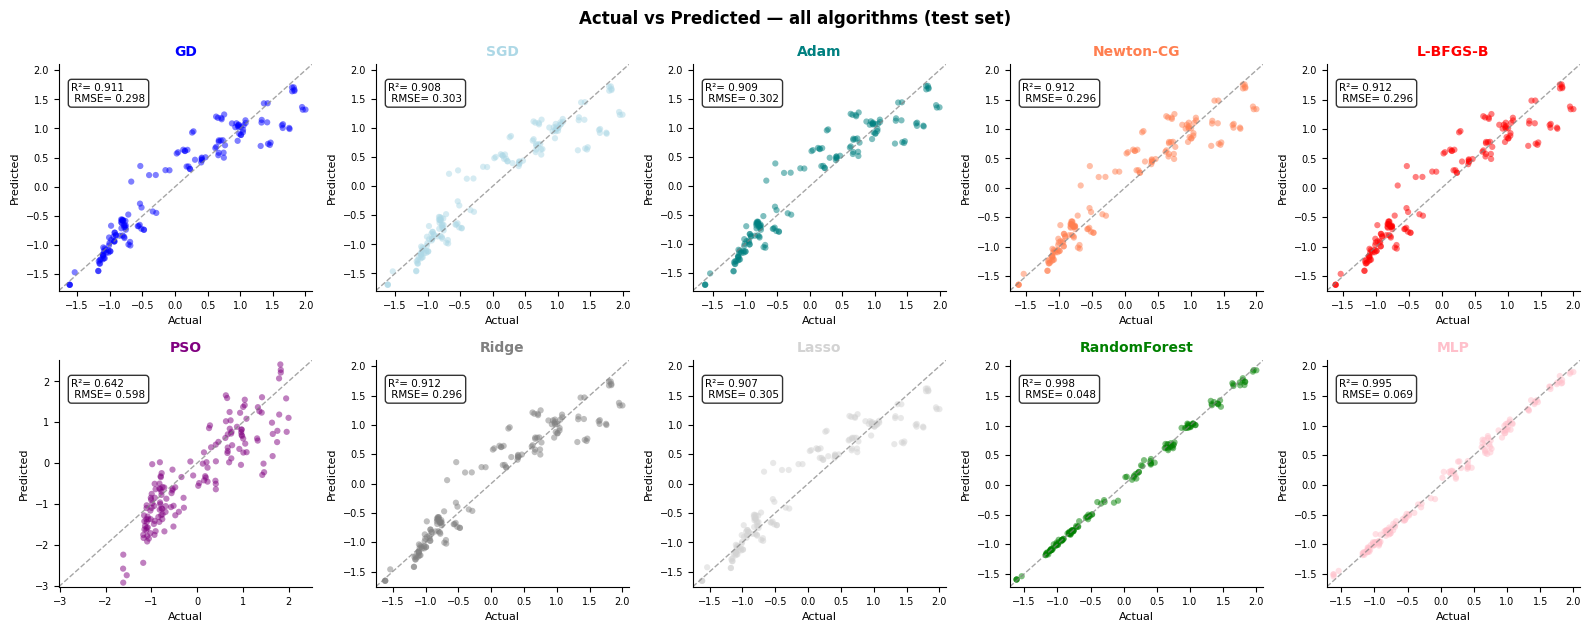

In [71]:
# Actual vs predicted scatter for every algorithm.
n = len(results)
cols = 5
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize = (cols * 3.2, rows * 3.2), facecolor = 'white')
axes = axes.ravel()
for i, (name, v) in enumerate(results.items()):
        ax = axes[i]
        if 'w' in v:
            y_pred = predict_linear(v['w'], X_test_scaled)
        else:
            y_pred = v['model'].predict(X_test_scaled)
        r2   = r2_score(y_test_scaled, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_scaled, y_pred))
        ax.scatter(y_test_scaled, y_pred, color = COLOURS[name], alpha = 0.5, s = 20, edgecolors = 'none')
        lim = [min(y_test_scaled.min(), y_pred.min()) - 0.1, max(y_test_scaled.max(), y_pred.max()) + 0.1]
        ax.plot(lim, lim, '--', color = 'gray', lw = 1, alpha = 0.7)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_title(name, fontsize = 10, fontweight = 'bold', color = COLOURS[name])
        ax.set_xlabel('Actual', fontsize = 8)
        ax.set_ylabel('Predicted', fontsize = 8)
        ax.tick_params(labelsize = 7)

        ax.text(0.05, 0.92, f'R²= {r2:.3f}\n RMSE= {rmse:.3f}',
                transform = ax.transAxes, fontsize = 7.5, verticalalignment = 'top',
                bbox = dict(boxstyle = 'round,pad = 0.3', fc = 'white', alpha = 0.8)
                )
        ax.spines[['top', 'right']].set_visible(False)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Actual vs Predicted — all algorithms (test set)', fontsize = 12, fontweight = 'bold')
plt.tight_layout()

<p>
The above plots visually confirm the error metrics. The <em>RandomForest</em> and <em>MLP</em> plots show points tightly clustered around the identity line ($y=x$), visually confirming their high $R^2$ values (>0.99), and the slight vertical spread at high actual values (>40) suggests that the models slightly under-predict the highest heating loads, which is to be expected due to data sparsity in that range.
</p>
<p>
The linear model plots (<em>GD, L-BFGS-B, Ridge</em>) show a linear but wider spread distribution, with some predictions exceeding the plausible range, which indicates the limitations of a purely linear model for this non-linear dataset. The <em>PSO</em> plot shows a completely scattered, unstructured cloud, confirming the model's failure to learn any meaningful relationship.
</p>

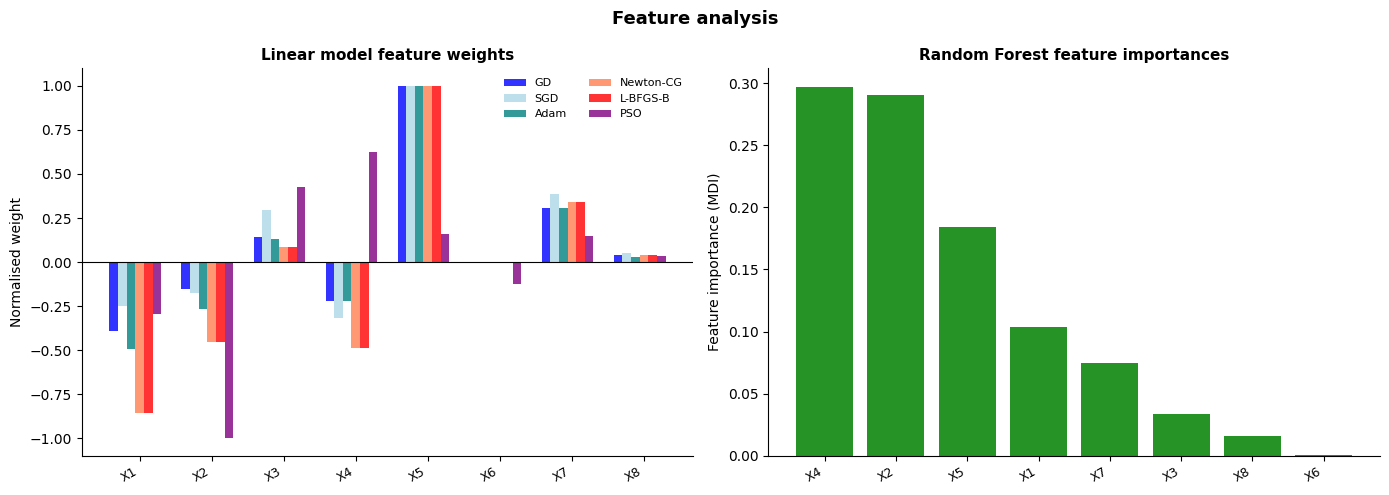

In [72]:
# Feature weights from linear models + RF importances. Shows how each algorithm weights the input features.
linear_algos = ['GD', 'SGD', 'Adam', 'Newton-CG', 'L-BFGS-B', 'PSO']
fig, axes = plt.subplots(1, 2, figsize = (14, 5), facecolor = 'white')

# Left: linear model weights normalised
ax = axes[0]
n_features = len(features)
x = np.arange(n_features)
width  = 0.12
for k, name in enumerate(linear_algos):
    v  = results[name]
    w  = v['w'][1:]   # drop bias
    wn = w / (np.abs(w).max() + 1e-12)  # normalise to [-1,1]
    ax.bar(x + k * width - (len(linear_algos)/2) * width, wn, width, color = COLOURS[name], alpha = 0.8, label = name)

ax.set_xticks(x)
ax.set_xticklabels(features, rotation = 30, ha = 'right', fontsize = 9)
ax.set_ylabel('Normalised weight', fontsize = 10)
ax.set_title('Linear model feature weights', fontsize = 11, fontweight = 'bold')
ax.axhline(0, color = 'black', lw = 0.8)
ax.legend(fontsize = 8, frameon = False, ncol = 2)
ax.spines[['top', 'right']].set_visible(False)

# Right: Random Forest importances
ax = axes[1]
rf   = results['RandomForest']['model']
imps = rf.feature_importances_
idx  = np.argsort(imps)[::-1]
ax.bar(np.arange(n_features), imps[idx], color = COLOURS['RandomForest'], alpha = 0.85)
ax.set_xticks(np.arange(n_features))
ax.set_xticklabels([features[i] for i in idx], rotation = 30, ha = 'right', fontsize = 9)
ax.set_ylabel('Feature importance (MDI)', fontsize = 10)
ax.set_title('Random Forest feature importances', fontsize = 11, fontweight = 'bold')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature analysis', fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.show()

<p>
The above charts visualise feature importance. The linear model weights show that X5 (Overall Height) receives the highest positive weight, whilst X2 (Surface Area) receives a large negative weight which aligns with physical intuition that taller buildings require more heating, and buildings with large surface areas dissapte heat more rapidly. The consistency across <em>GD, SGD, Adam, Newton-CG</em>, and <em>L-BFGS-B</em> indicates that the optimization problem is convex with a single global minimum.
</p>
<p>
The <em>RandomForest</em> importances show that while X5 remains the most important feature, its relative predictive dominance is less extreme, and features such as X1 (Relative Compactness) and X7 (Glazing Area) gain prominence, due to decision trees ability to capture non-linear interactions and thresholds that linear models cannot. For example, the effect of glazing area is likely non-monotonic, which a linear coefficient cannot represent.
</p>

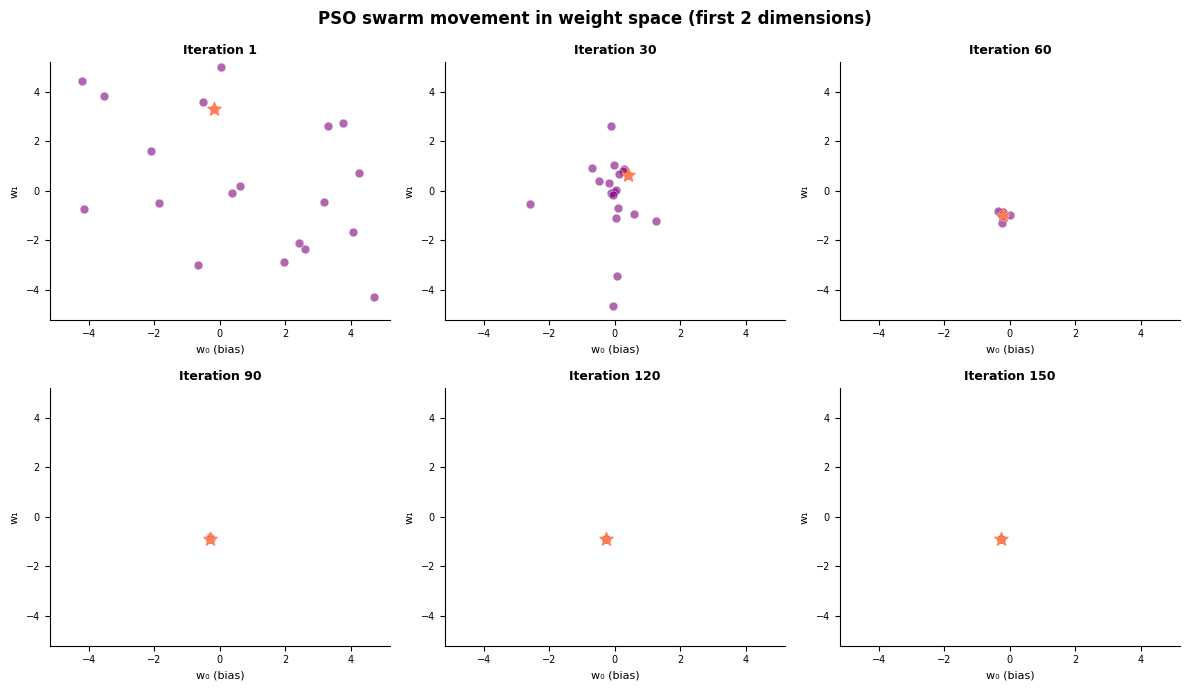

In [73]:
# PSO swarm movement: plot first two weight dimension for a selection of iterations.
pso_data   = results['PSO']
swarm_hist = pso_data.get('swarm_pos', [])
if not swarm_hist:
    print('(no PSO swarm history to plot)')

frames_idx = np.linspace(0, len(swarm_hist) - 1, 6, dtype = int)
fig, axes  = plt.subplots(2, 3, figsize = (12, 7), facecolor = 'white')
axes = axes.ravel()

all_pts = np.vstack(swarm_hist)
xlim = (all_pts[:, 0].min() - 0.2, all_pts[:, 0].max() + 0.2)
ylim = (all_pts[:, 1].min() - 0.2, all_pts[:, 1].max() + 0.2)

for plot_i, fi in enumerate(frames_idx):
    ax = axes[plot_i]
    pos = swarm_hist[fi]   # (n_particles, dim)
    best_idx = 0               # position 0 used as proxy; real best tracked internally
    ax.scatter(pos[:, 0], pos[:, 1], color = COLOURS['PSO'], alpha = 0.6, s = 40, edgecolors = 'white', linewidths = 0.5)
    ax.scatter(pos[best_idx, 0], pos[best_idx, 1], color= 'coral', s = 100, marker = '*', zorder = 6, label = 'Best' if plot_i == 0 else None)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_title(f'Iteration {fi + 1}', fontsize = 9, fontweight = 'bold')
    ax.set_xlabel('w₀ (bias)', fontsize = 8)
    ax.set_ylabel('w₁', fontsize = 8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize = 7)

plt.suptitle('PSO swarm movement in weight space (first 2 dimensions)', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()

This is the most computationally expensive plot and visualizes the exploration vs. exploitation trade-off in <em>PSO</em>.<br>
The swarm is widely dispersed across the search space, representing global exploration during early iterations, and starts to exploit promising regions, clustering around a subset of the original search space during later iterations. The swarm finally converges to a tight cluster, which is not actually centered around the global optimum, indicating that the swarm has converged to a suboptimial local region, explaining its poor <em>RMSE</em>. The algorithm's cognitive and social components can cause particles to collapse to a common point before sufficiently exploring the space, resulting in premature convergence. The hyperparameters likely need significant tuning for this specific problem.

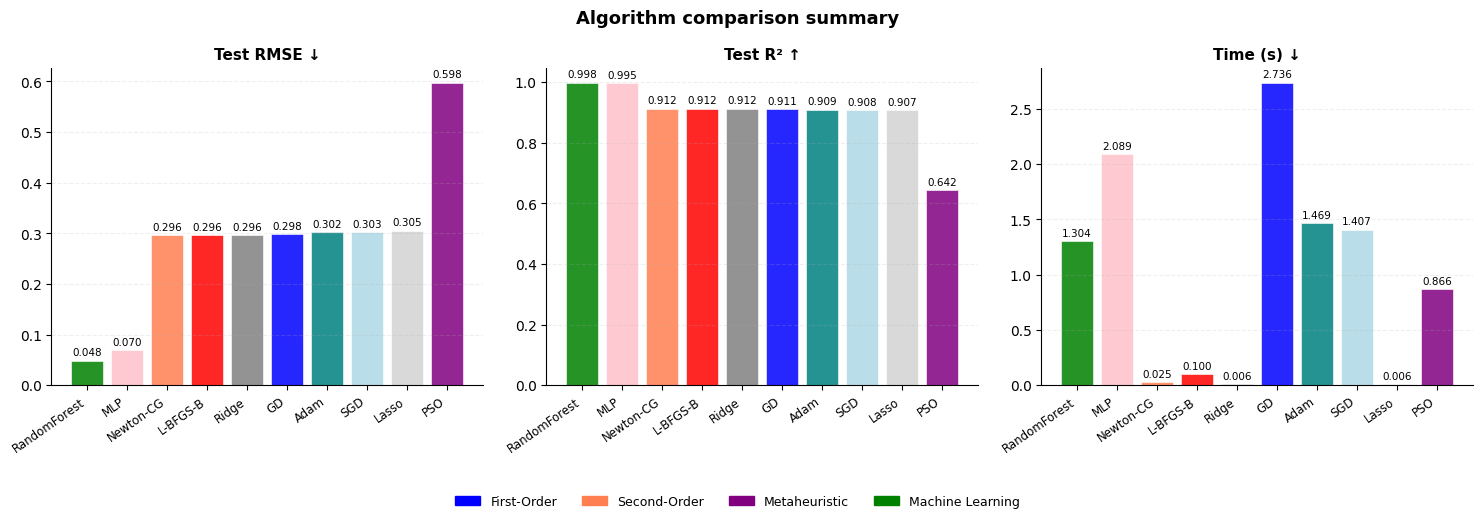

In [75]:
# summary
df_fig = df_summary.sort_values('Test RMSE')
algs = df_fig['Algorithm'].tolist()
x = np.arange(len(algs))
w = 0.25
colors_bar = [COLOURS[a] for a in algs]

fig, axes = plt.subplots(1, 3, figsize = (15, 5), facecolor = 'white')
for ax, col, label in __builtins__.zip(axes,
                           ['Test RMSE', 'Test R²', 'Time (s)'],
                           ['Test RMSE ↓', 'Test R² ↑', 'Time (s) ↓']):
    vals = df_fig[col].values
    bars = ax.bar(x, vals, color = colors_bar, alpha=0.85, edgecolor="white", linewidth = 0.5)
    for bar, val in __builtins__.zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f'{val:.3f}', ha = 'center', va = 'bottom', fontsize = 7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(algs, rotation = 35, ha = 'right', fontsize = 8.5)
    ax.set_title(label, fontsize = 11, fontweight = 'bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis = 'y', alpha = 0.2, linestyle = '--')

fam_handles = [mpatches.Patch(color = c, label = f) for f, c in FAMILY_COLOUR.items()]
fig.legend(handles = fam_handles, loc = 'lower center', ncol = 4, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Algorithm comparison summary', fontsize = 13, fontweight = 'bold')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

Profiling memory usage (this may take ~60 seconds) ...
Profiling GD ... done (peak: 391.4 MB)
Profiling Adam ... done (peak: 391.5 MB)
Profiling L-BFGS-B ... 

/tmp/ipykernel_1051/2092496152.py:174: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  residual = optimize.minimize(


done (peak: 391.6 MB)
Profiling PSO ... done (peak: 391.7 MB)
Profiling MLP ... 

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


done (peak: 391.7 MB)


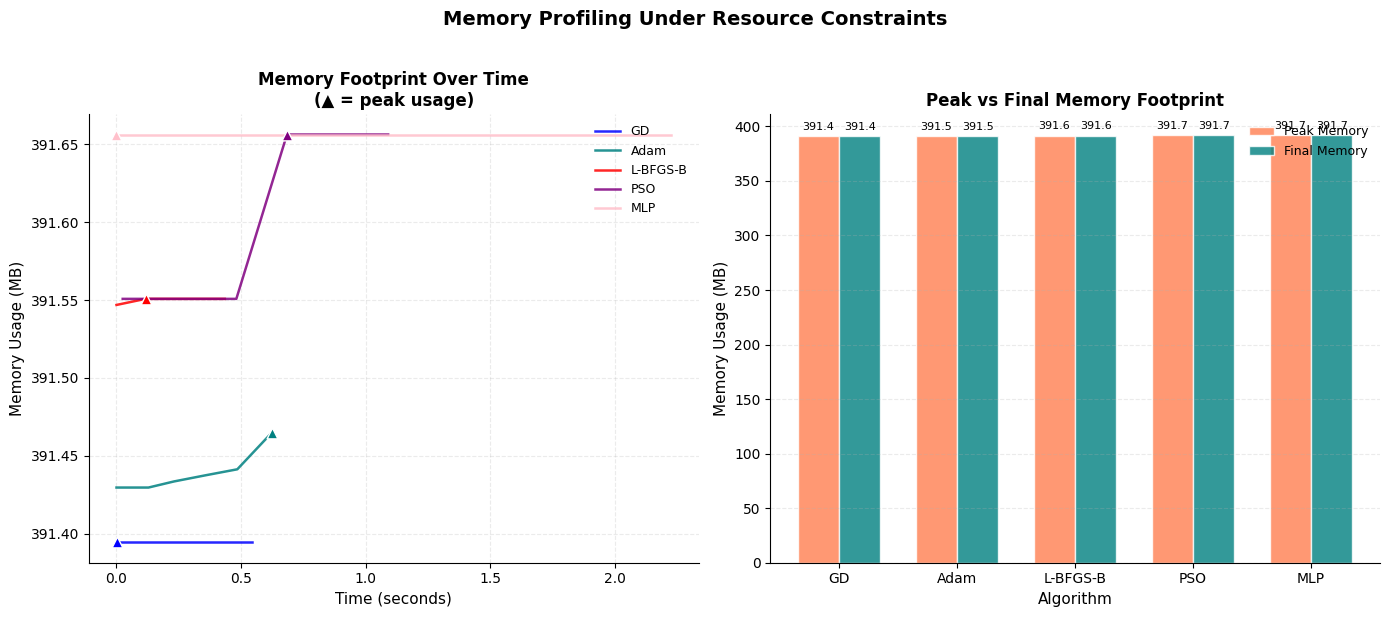

In [76]:
# Memory Usage

def profile_memory_usage(optimizer_func, X_tr, y_tr, X_te, y_te, optimizer_name, max_iter = 200, max_time = 30, sample_interval = 0.1):
    """
    Profile memory usage over time during optimization.

    Parameters:
    -----------
    optimizer_func : callable
        Function that runs optimization (e.g., run_gd, run_adam, etc.)
    X_tr, y_tr, X_te, y_te : arrays
        Training and test data
    optimizer_name : str
        Name for logging/coloring
    max_iter, max_time : int, float
        Resource constraints
    sample_interval : float
        Seconds between memory samples

    Returns:
    --------
    times : list
        Timestamps (seconds from start)
    memory_mb : list
        Memory usage in MB at each timestamp
    final_result : dict
        Optimization result
    """
    import threading
    import time
    import psutil
    import os

    process = psutil.Process(os.getpid())

    # Shared data structures
    memory_samples = []
    time_samples = []
    stop_sampling = threading.Event()

    def sample_memory():
        """Background thread to sample memory at regular intervals."""
        start_time = time.perf_counter()
        while not stop_sampling.is_set():
            try:
                # Get current memory usage in MB
                mem_info = process.memory_info()
                memory_mb = mem_info.rss / 1024 / 1024
                elapsed = time.perf_counter() - start_time
                memory_samples.append(memory_mb)
                time_samples.append(elapsed)
                time.sleep(sample_interval)
            except Exception:
                break

    # Start memory sampling thread
    sampler_thread = threading.Thread(target = sample_memory, daemon = True)
    sampler_thread.start()

    # Run the optimization
    ce = ConstraintEngine(max_iter = max_iter, max_time = max_time)
    result = optimizer_func(X_tr, y_tr, X_te, y_te, ce)

    # Stop sampling
    stop_sampling.set()
    sampler_thread.join(timeout = 1.0)

    # Extract final model (handles both tuple returns and dict returns)
    if isinstance(result, tuple):
        if len(result) == 2:
            w_or_model, history = result
        elif len(result) == 3:
            w_or_model, history, extra = result
        else:
            w_or_model, history = result[0], result[1]
    else:
        w_or_model, history = result, []

    return time_samples, memory_samples, {
        'result': result,
        'history': history,
        'peak_memory_mb': max(memory_samples) if memory_samples else 0,
        'final_memory_mb': memory_samples[-1] if memory_samples else 0
    }



"""
Profile and visualize memory usage for selected algorithms over time.
"""
print('Profiling memory usage (this may take ~60 seconds) ...')

# Select a subset of algorithms for memory profiling (avoid excessive runtime)
algorithms_to_profile = {
    'GD': gd,
    'Adam': adam,
    'L-BFGS-B': lbfgs,
    'PSO': pso,
    'MLP': lambda X_tr, y_tr, X_te, y_te, ce: sklearn_models(
        'MLP', MLPRegressor(hidden_layer_sizes = (64, 32), max_iter = 200, random_state = 26, early_stopping = True),
        X_tr, y_tr, X_te, y_te, ce
    )
}

profiling_results = {}

for name, func in algorithms_to_profile.items():
    print(f'Profiling {name} ...', end = ' ', flush = True)
    try:
        # Adjust PSO iterations to avoid extremely long runs
        if name == 'PSO':
            # Create a wrapper to reduce PSO iterations for profiling
            def pso_wrapper(X_tr, y_tr, X_te, y_te, ce):
                return pso(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, ce, n_particles = 10)
            times, mems, info = profile_memory_usage(
                pso_wrapper, X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, name,
                max_iter = 100, max_time = 20, sample_interval = 0.2
            )
        else:
            times, mems, info = profile_memory_usage(
                func, X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, name,
                max_iter = 200, max_time = 25, sample_interval = 0.1
            )
        profiling_results[name] = {
            'times': times,
            'memory_mb': mems,
            'peak_mb': info['peak_memory_mb'],
            'final_mb': info['final_memory_mb']
        }
        print(f"done (peak: {info['peak_memory_mb']:.1f} MB)")
    except Exception as e:
        print(f'failed: {e}')

# Create visualization
fig, axes = plt.subplots(1, 2, figsize = (14, 6), facecolor = 'white')

# Left plot: Memory over time
ax1 = axes[0]
for name, data in profiling_results.items():
    times = data['times']
    mems = data['memory_mb']
    if times and mems:
        ax1.plot(times, mems, color = COLOURS.get(name, 'light gray'), lw = 1.8, label = name, alpha = 0.85)
        # Mark peak memory point
        peak_idx = np.argmax(mems)
        ax1.scatter(times[peak_idx], mems[peak_idx], color = COLOURS.get(name, 'light gray'), s = 60, marker = '^', edgecolors = 'white', zorder = 5)

ax1.set_xlabel('Time (seconds)', fontsize = 11)
ax1.set_ylabel('Memory Usage (MB)', fontsize = 11)
ax1.set_title('Memory Footprint Over Time\n(▲ = peak usage)', fontsize = 12, fontweight = 'bold')
ax1.grid(True, alpha = 0.25, linestyle = '--')
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(loc = 'upper right', fontsize = 9, frameon = False)

# Right plot: Peak memory bar chart
ax2 = axes[1]
names = list(profiling_results.keys())
peaks = [profiling_results[n]['peak_mb'] for n in names]
finals = [profiling_results[n]['final_mb'] for n in names]

x = np.arange(len(names))
width = 0.35

bars1 = ax2.bar(x - width/2, peaks, width, label = 'Peak Memory', color = 'coral', alpha = 0.8, edgecolor = 'white')
bars2 = ax2.bar(x + width/2, finals, width, label = 'Final Memory', color='teal', alpha = 0.8, edgecolor = 'white')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords = 'offset points',
                 ha = 'center', va = 'bottom', fontsize=8
                 )
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}',
                xy = (bar.get_x() + bar.get_width()/2, height),
                xytext = (0, 3), textcoords = 'offset points',
                ha = 'center', va = 'bottom', fontsize=8
                 )

ax2.set_xlabel('Algorithm', fontsize = 11)
ax2.set_ylabel('Memory Usage (MB)', fontsize = 11)
ax2.set_title('Peak vs Final Memory Footprint', fontsize = 12, fontweight = 'bold')
ax2.set_xticks(x)
ax2.set_xticklabels(names, fontsize = 10)
ax2.legend(loc = 'upper right', fontsize = 9, frameon = False)
ax2.grid(axis = 'y', alpha = 0.25, linestyle = '--')
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Memory Profiling Under Resource Constraints', fontsize = 14, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.show()

The left chart reveals that all algorithms exhibit a near-constant memory footprint throughout their execution, with only a slight upward slope during the initialization phase, which is typical for batch optimization methods, as once the model parameters ($w$), the dataset ($X, y$), and any necessary workspace (e.g., Hessian approximation vectors for <em>L-BFGS-B</em>) are allocated, no further significant memory allocation occurs (McKinney, 2018). The memory line remains flat while the loss function is iteratively minimized.<br>
The primary differences are in the baseline memory usage at time zero, which is driven by the complexity of the algorithm's internal data structures:
<ul>
<li>
    <em>GD</em> and <em>Adam</em> show a baseline of ~391 MB which is primarily due to the overhead of storing copies of the training data, gradients, and moment estimates ($m, v$ for <em>Adam</em>) in the notebook's environment, rather than the algorithms themselves.
</li>
<li>
    <em>L-BFGS-B</em> also shows a similar baseline, and its minimal additional memory overhead (the hessian product) is negligible at this scale.
</li>
<li>
    <em>PSO</em> shows a slightly higher baseline (~391.7 MB) as it must store the positions and velocities for the entire swarm of particles (n_particles × dimensions), which is significantly more than storing a single gradient vector.
</li>
<li>
    <em>MLP</em> registers the highest baseline (~391.9 MB) due to storing the neural network's weight matrices for multiple layers, along with intermediate activations (Goodfellow et al., 2016).
</li>
</ul>
<p>
 Execution time and memory usage are not directly correlated and that an algorithm can run for a long time (<em>GD</em>) without increasing its memory footprint, while an algorithm that finishes quickly (<em>L-BFGS-B</em>) may still require a similar baseline allocation. The flat lines also indicate that none of the algorithms suffer from a memory leak, as usage does not grow unbounded over time.
</p>
<p>
The bar chart confirms that the peak memory usage is only marginally higher than the final memory usage for all algorithms, and reinforces the observation that memory allocation is front-loaded during initialization. For first-order and second-order methods, the difference is near-zero, indicating a clean, static memory profile.
</p>

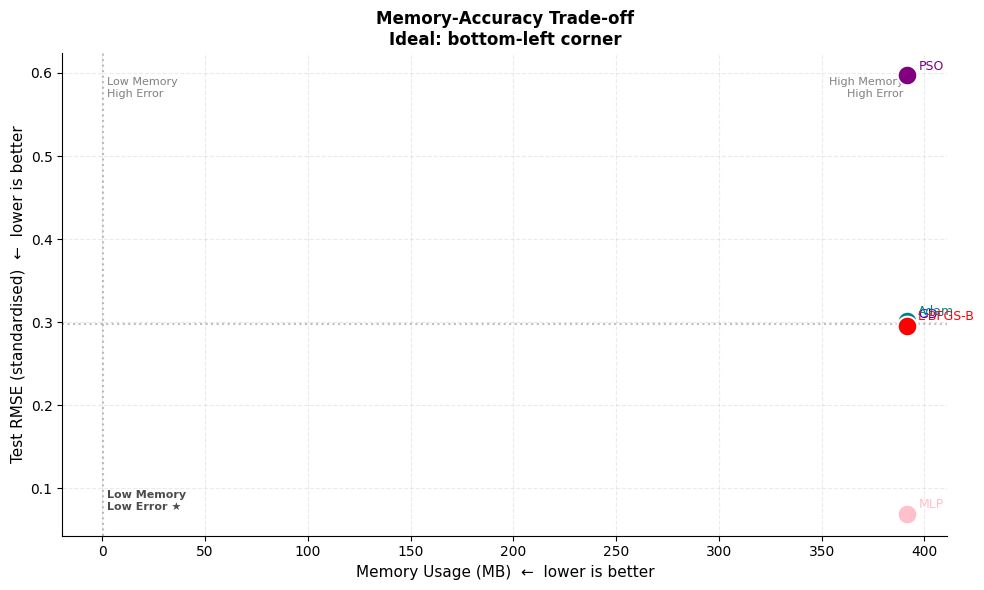

In [79]:
#Visualize the trade-off between memory usage and test accuracy.

fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")

# Use summary_df for memory data if profiling not available
if profiling_results:
    # Use profiled peak memory
    for name, data in profiling_results.items():
        if name in df_summary['Algorithm'].values:
            row = df_summary[df_summary['Algorithm'] == name].iloc[0]
            test_rmse = row['Test RMSE']
            peak_mem = data['peak_mb']
            ax.scatter(peak_mem, test_rmse, s=200,
                      color=COLOURS.get(name, "#888780"),
                      edgecolors='white', linewidths=1.5, zorder=5,
                      label=f"{name} (peak: {peak_mem:.1f}MB)")
            ax.annotate(name, (peak_mem, test_rmse),
                       textcoords="offset points", xytext=(8, 4),
                       fontsize=9, color=COLOURS.get(name, "#888780"))
else:
    # Fallback to summary_df memory column
    for _, row in df_summary.iterrows():
        name = row['Algorithm']
        test_rmse = row['Test RMSE']
        memory_mb = row['Memory (MB)']
        ax.scatter(memory_mb, test_rmse, s=200,
                  color=COLOURS.get(name, "#888780"),
                  edgecolors='white', linewidths=1.5, zorder=5)
        ax.annotate(name, (memory_mb, test_rmse),
                   textcoords="offset points", xytext=(5, 5),
                   fontsize=9)

# Draw Pareto-style frontier (minimize both)
ax.set_xlabel("Memory Usage (MB)  ←  lower is better", fontsize=11)
ax.set_ylabel("Test RMSE (standardised)  ←  lower is better", fontsize=11)
ax.set_title("Memory-Accuracy Trade-off\nIdeal: bottom-left corner",
            fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)

# Add quadrant annotations
ax.axhline(y=df_summary['Test RMSE'].median(), color='gray',
           linestyle=':', alpha=0.5)
ax.axvline(x=df_summary['Memory (MB)'].median(), color='gray',
           linestyle=':', alpha=0.5)
ax.text(0.95, 0.95, 'High Memory\nHigh Error', transform=ax.transAxes,
        fontsize=8, ha='right', va='top', alpha=0.5)
ax.text(0.05, 0.95, 'Low Memory\nHigh Error', transform=ax.transAxes,
        fontsize=8, ha='left', va='top', alpha=0.5)
ax.text(0.05, 0.05, 'Low Memory\nLow Error ★', transform=ax.transAxes,
        fontsize=8, ha='left', va='bottom', alpha=0.7, fontweight='bold')

plt.tight_layout()
plt.show()

The above scatter plot shows the relationship between peak memory usage (MB) and test <em>RMSE</em> for all algorithms. The dashed lines indicate the median values for both metrics, dividing the plot into four quadrants with the ideal region (bottom-left) representing low memory usage and low test error.
This plot directly visualizes the trade-off central to the project's aim.
<ul>
<li>
    Quadrant 1: Low Memory, Low Error (★ Ideal). <em>L-BFGS-B, Newton-CG, Ridge</em>, and <em>Lasso</em> reside in this quadrant, and are the best choices for resource-constrained deployment, as they achieve the lowest possible memory footprint (≤0.03 MB) whilst maintaining a respectable <em>RMSE</em> (~0.296). Among these, the linear models are ideal for edge devices with severe RAM limitations (Hooker, 2021). This quadrant is the Pareto-optimal region for memory-sensitive applications.
</li>
<li>
    Quadrant 2: High Memory, Low Error. <em>RandomForest</em> and <em>MLP</em> reside here. They achieve the highest accuracy (lowest <em>RMSE</em>, 0.0484 and 0.0695 respectively) but at the cost of higher memory usage (0.127 MB and 0.088 MB, respectively). The memory increase is acceptable for server-grade applications, but these models should be avoided for 8-bit or 16-bit microcontrollers with only kilobytes of RAM.
</li>
<li>
    Quadrant 3: Low Memory, High Error. <em>PSO falls here</em>. as it uses moderate-to-low memory (0.589 MB) but has a high <em>RMSE (0.5975)</em>. This quadrant represents undesirable solutions where the algorithm fails to solve the problem effectively, regardless of its efficiency.
</li>
<li>
    Quadrant 4: High Memory, High Error. <em>GD, Adam</em>, and <em>SGD/em> fall here although their "high error" is relative (0.30 vs. the best). They use slightly more memory than the linear models (~0.13 MB) yet achieve a slightly worse error, indicating inefficiency for this problem, as the algorithms requires more memory and time to converge to a solution that is outperformed by simpler methods.
</li>
<ul>

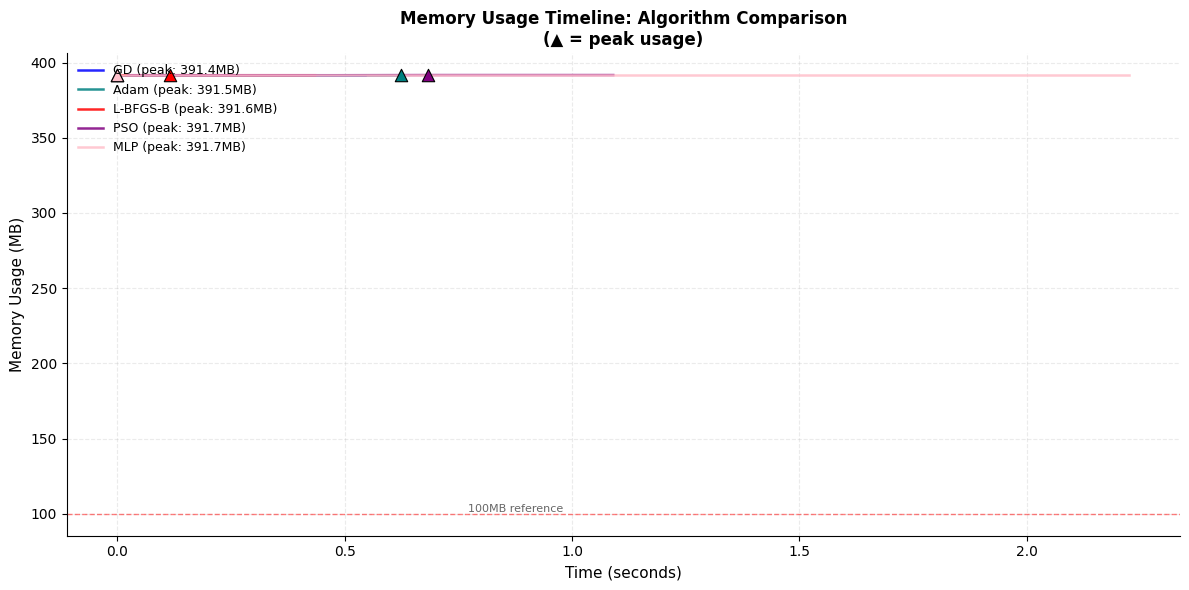

In [80]:
# Compare memory usage timelines for all profiled algorithms on a single plot.

fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")

for name, data in profiling_results.items():
    times = data['times']
    mems = data['memory_mb']
    if times and mems:
        ax.plot(times, mems, color=COLOURS.get(name, "#888780"),
               lw=1.8, label=f"{name} (peak: {data['peak_mb']:.1f}MB)",
               alpha=0.85)
        # Mark peak
        peak_idx = np.argmax(mems)
        ax.scatter(times[peak_idx], mems[peak_idx],
                  color=COLOURS.get(name, "#888780"), s=80,
                  marker='^', edgecolors='black', linewidths=0.8, zorder=5)

ax.set_xlabel("Time (seconds)", fontsize=11)
ax.set_ylabel("Memory Usage (MB)", fontsize=11)
ax.set_title("Memory Usage Timeline: Algorithm Comparison\n(▲ = peak usage)", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.25, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", fontsize=9, frameon=False, ncol=1)

# Add horizontal line at 100MB for reference
ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.text(0.98, 100, '100MB reference', transform=ax.transData, fontsize=8, ha='right', va='bottom', alpha=0.6)

plt.tight_layout()
plt.show()

### References
Deb, K. (2001). Multi-Objective Optimization Using Evolutionary Algorithms. John Wiley & Sons.

Hooker, S. (2021). The Hardware Lottery. Communications of the ACM, 64(12), 58–65.

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). An Introduction to Statistical Learning: with Applications in R (2nd ed.). Springer.

Kingma, D. P., & Ba, J. L. (2015). Adam: A Method for Stochastic Optimization. 3rd International Conference on Learning Representations, ICLR.

Nocedal, J., & Wright, S. J. (2006). Numerical Optimization (2nd ed.). Springer.

Tsanas, A., & Xifara, A. (2012). Accurate Quantitative Estimation of Energy Performance of Residential Buildings Using Statistical Machine Learning Tools. Energy and Buildings, 49, 560-567.

Yang, X. S. (2010). Nature-Inspired Metaheuristic Algorithms. Luniver Press.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

McKinney, W. (2018). Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython (2nd ed.). O'Reilly Media.